In [2]:
"""
Figure 3 (MNIST / CIFAR-10 / CIFAR-100) — RBF vs VP-Norm (STD) denoising

This noteboke is a self-contained implementation of Figure 3 from
“From Softmax to Score: Transformers Can Effectively Implement In-Context
Denoising Steps”.

What it does
------------
For each dataset (MNIST, CIFAR-10, CIFAR-100), and for each kernel:
    • RBF  : exact Gaussian kernel denoiser
    • VPNorm (STD): variance-preserving update on the unit sphere

we:
    1. Build a 6-layer denoising Transformer.
    2. Initialise it with the theoretical VE/VP reverse-ODE schedule:
           σ_k  = σ_0 ρ^k,   γ_k = (1 − ρ²) / 2,
       with ρ chosen so that σ_min = 10⁻³ σ_0.
       - For RBF:   σ_0 = NOISE_STD
       - For VPNorm: σ_0 = NOISE_STD / E[‖x‖], matching unit-normalised noise
    3. Evaluate layer-wise test RMSE (and optional FID).
    4. Fine-tune from this theory initialisation with early stopping
       (RMSE-based), and re-evaluate layer-wise metrics.

We repeat (2)–(4) for several random seeds. Each seed has its own random
train/test split (90/10) and its own training RNG. We then:
    • plot layer-wise progression (test loss vs. layer index ℓ),
    • print compact tables of mean ± std over seeds.

We do save and reuse checkpoints:

    • Checkpoints live under: ./models/figure3/{dataset_name}/
    • Filenames encode dataset, kernel, mode, L, epoch, lr, σ, and seed.
    • On a rerun, we look for the highest-epoch checkpoint matching that
      pattern and reuse it, unless RETRAIN=True.

"""

import math
import re
from pathlib import Path
from typing import Dict, Tuple, List, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.cuda.amp import autocast, GradScaler


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


TARGET_LAYER = 6

# Global scalar noise level in raw pixel space*
# For RBF this is σ_0; for VPNorm we rescale by the mean norm.
NOISE_STD = 1.0

# Learning rate used in all training; kept explicit so it appears in
LR_INIT = 1e-3

# Where we store checkpoints (one directory per dataset).
BASE_DIR = Path("./models/figure3")
BASE_DIR.mkdir(parents=True, exist_ok=True)

# Toggle: if True, ignore existing checkpoints and retrain from scratch.
RETRAIN = False

# Dataset-specific hyperparameters 
CONFIGS = {
    "mnist": {
        "batch_size": 4096,
        "patience": 3,
        "tol_rmse": 1e-3,
        "max_epochs": 500,
        "min_epochs": 50,
        "seeds": [0, 1, 2],
        "dims": 784,
    },
    "cifar10": {
        "batch_size": 2048, 
        "patience": 15,
        "tol_rmse": 1e-4,
        "max_epochs": 500,
        "min_epochs": 50,
        "seeds": [0, 1, 2],
        "dims": 3072,
    },
    "cifar100": {
        "batch_size": 2048,
        "patience": 15,
        "tol_rmse": 1e-4,
        "max_epochs": 500,
        "min_epochs": 50,
        "seeds": [0, 1, 2],
        "dims": 3072,
    },
}

DATA_DIR = Path("./data")

# Optional FID metric (CIFAR-10/100 only)
try:
    from torchmetrics.image.fid import FrechetInceptionDistance

    HAS_FID = True
except ImportError:
    HAS_FID = False
    print("Warning: torchmetrics not installed. FID will be skipped.")


In [3]:


# Data loading and per-seed 90/10 splits

def get_data_tensors(dataset_name: str, split_seed: int) -> Dict[str, object]:
    """
    Load a dataset, flatten images to R^d, and build a per-seed 90/10 split.

    Args
    ----
    dataset_name : {"mnist", "cifar10", "cifar100"}
    split_seed   : integer seed used only for the train/test split.

    Returns
    -------
    A dict with:
        • train_raw  : [N_train, d] raw pixels in [0,1]
        • train_unit : [N_train, d] unit-normalised train_raw
        • train_norms: [N_train, 1] ℓ₂ norms of train_raw
        • test_raw   : [N_test, d]
        • test_norms : [N_test, 1]
        • train_idx  : local index tensor 0..N_train-1
        • test_idx   : local index tensor 0..N_test-1
        • n_train    : int
        • mean_norm  : E[‖x‖] over the train split (used for VPNorm σ₀).
    """
    cfg = CONFIGS[dataset_name]

    to_flat = T.Compose([
        T.ToTensor(),          # [C,H,W] in [0,1]
        T.Lambda(lambda x: x.view(-1)),  # flatten to [d]
    ])

    print(f"Loading {dataset_name} (split seed {split_seed})...")

    if dataset_name == "mnist":
        ds = torchvision.datasets.MNIST(
            DATA_DIR, train=True, download=True, transform=to_flat
        )
    elif dataset_name == "cifar10":
        ds = torchvision.datasets.CIFAR10(
            DATA_DIR, train=True, download=True, transform=to_flat
        )
    elif dataset_name == "cifar100":
        ds = torchvision.datasets.CIFAR100(
            DATA_DIR, train=True, download=True, transform=to_flat
        )
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    raw_all = torch.stack([x for x, _ in ds]).to(DEVICE)  # [N, d]
    N = raw_all.size(0)
    n_train = int(0.9 * N)

    # Per-seed split: each seed sees a different 90/10 split.
    torch.manual_seed(split_seed)
    perm = torch.randperm(N, device=DEVICE)
    train_idx_raw, test_idx_raw = perm[:n_train], perm[n_train:]

    train_raw = raw_all[train_idx_raw]
    test_raw = raw_all[test_idx_raw]

    # Norms and unit-direction copies (for STD / VPNorm model)
    train_norms = train_raw.norm(dim=1, keepdim=True).clamp_min(1e-8)
    test_norms = test_raw.norm(dim=1, keepdim=True).clamp_min(1e-8)
    train_unit = train_raw / train_norms

    mean_norm = train_norms.mean().item()

    train_idx = torch.arange(train_raw.size(0), device=DEVICE)
    test_idx = torch.arange(test_raw.size(0), device=DEVICE)

    return {
        "train_raw": train_raw,
        "train_unit": train_unit,
        "train_norms": train_norms,
        "test_raw": test_raw,
        "test_norms": test_norms,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "n_train": train_raw.size(0),
        "mean_norm": mean_norm,
    }



In [4]:

## 3. Models: one denoising layer and an L-layer stack

def softplus_inv(y: float) -> float:
    """
    Numerically stable inverse of softplus on scalars.

    We store positive parameters (γ, 1/σ²) in log-softplus form, so to set a
    desired positive value α we write:
        param.data.fill_(softplus_inv(α)).
    """
    if y <= 0.0:
        return -20.0  # softplus(-20) ≈ 2e-9
    return math.log(math.expm1(y)) if y < 20.0 else y + math.log1p(-math.exp(-y))


class DenoiseLayer(nn.Module):
    """
    Single denoising layer implementing a kernel-weighted update.

    For a query q and dictionary keys K, the layer performs:

        1. Compute attention weights w(q, x_j) over keys {x_j} via either:
           - RBF kernel in R^d (exact KDE update), or
           - VPNorm kernel on the *unit sphere*, with a VP-style reparameterisation.

        2. Form the conditional mean m(q) = Σ_j w_j x_j.

        3. Take one Euler step in the denoising ODE:
               q_next = q + γ (m(q) − q)          (RBF / VE)
           or, for VPNorm, the analogous step in the VP-rescaled frame.

    This exactly matches the kernel-weighted updates analysed in the paper
    (Sections 2–4) for both manifold denoising and score-based denoising.
    """

    def __init__(self, kernel: str):
        super().__init__()
        assert kernel in ("rbf", "vpnorm")
        self.kernel = kernel
        # log_inv_sigma2 ~ log(softplus^{-1}(1/σ²)), log_gamma ~ log(softplus^{-1}(γ))
        self.log_inv_sigma2 = nn.Parameter(torch.zeros(()))
        self.log_gamma = nn.Parameter(torch.zeros(()))

    @staticmethod
    def _vp_coeffs(inv_sigma2: torch.Tensor, gamma: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Variance-preserving (VP) coefficients α_k, α_{k+1}.

        For an underlying VE (variance-exploding) σ_k² schedule with step size
        γ_k, one can reparameterise into a VP-style sequence with per-step
        scaling α_k ≈ (1 + σ_k²)^{-1/2}.  This is the usual VE ←→ VP mapping
        used in score-based diffusion, but here we keep it in closed form
        at the layer level.
        """
        sigma2 = 1.0 / inv_sigma2
        sigma2_next = sigma2 - gamma * sigma2
        alpha_k = torch.sqrt(1.0 / (1.0 + sigma2))
        alpha_k_next = torch.sqrt(1.0 / (1.0 + sigma2_next))
        return alpha_k, alpha_k_next

    def forward(self, keys: torch.Tensor, queries: torch.Tensor) -> torch.Tensor:
        """
        Args
        ----
        keys    : [M, d]   (training / context dictionary)
        queries : [B, d]   (current noisy points)

        Returns
        -------
        updated_queries : [B, d] after a single denoising step.
        """
        inv_sigma2 = F.softplus(self.log_inv_sigma2)
        gamma = F.softplus(self.log_gamma)

        if self.kernel == "rbf":
            # Exact RBF KDE:
            #   log k(q, x_j) ∝ -‖q - x_j‖² / (2σ²)
            q_norm = (queries ** 2).sum(dim=1, keepdim=True)          # [B,1]
            k_norm = (keys ** 2).sum(dim=1, keepdim=True).T           # [1,M]
            dist_sq = q_norm + k_norm - 2 * (queries @ keys.T)        # [B,M]
            logits = -0.5 * inv_sigma2 * dist_sq                      # [B,M]
            attn_weights = F.softmax(logits, dim=1)                   # [B,M]
            conditional_mean = attn_weights @ keys                    # [B,d]
            update = conditional_mean - queries
            return queries + gamma * update

        else:  # "vpnorm" — VP update in unit-normalised coordinates
            alpha_k, alpha_k_next = self._vp_coeffs(inv_sigma2, gamma)

            # Work in the VP frame: q_vp = q / α_k
            q_scaled = queries / alpha_k
            logits = inv_sigma2 * (q_scaled @ keys.T)                 # [B,M]
            attn_weights = F.softmax(logits, dim=1)                   # [B,M]

            conditional_mean = attn_weights @ keys                    # [B,d]
            q_vp_next = q_scaled + gamma * (conditional_mean - q_scaled)

            # Map back to the next VP frame
            return q_vp_next * alpha_k_next


class DenoiseTransformer(nn.Module):
    """
    L-layer denoising Transformer.

    Mathematically, this is just L repeated applications of the kernel-weighted
    update in DenoiseLayer, sharing a fixed dictionary of keys K (the train
    split).  Each layer has its own (γ_k, σ_k) pair.

    In the paper language:
        • RBF kernel corresponds to VE-style score-based denoising,
        • VPNorm corresponds to a VP reparameterisation on the unit sphere.
    """

    def __init__(self, n_layers: int, kernel: str = "rbf"):
        super().__init__()
        self.kernel = kernel
        self.layers = nn.ModuleList(
            [DenoiseLayer(kernel) for _ in range(n_layers)]
        )

    def forward(self, keys: torch.Tensor, queries: torch.Tensor) -> torch.Tensor:
        x = queries
        for layer in self.layers:
            x = layer(keys, x)
        return x


def theory_initialise(
    model: DenoiseTransformer,
    sigma0: float,
    sigma_min: Optional[float] = None,
) -> None:
    """
    Initialise (γ_k, σ_k) according to the closed-form reverse-ODE schedule.

    We follow the  schedule:

        • Geometric noise schedule:
              σ_k = σ_0 ρ^k,    k = 0, ..., L-1
          with ρ chosen so that σ_min = 10^{-3} σ_0 (by default).

        • Constant step size γ_*:
              γ_* = (1 - ρ^2) / 2,

          which is exactly the factor obtained by an Euler discretisation of the
          reverse VE/VP ODE (see Section 4 of the paper).

    This matches the behaviour of the original MNIST / CIFAR sweeps:
        - for RBF:    σ_0 = NOISE_STD,
        - for VPNorm: σ_0 = NOISE_STD / E[‖x‖] (unit-normalised noise level).

    All layers are frozen after initialisation; we re-enable gradients
    explicitly when fine-tuning the "trained" models.
    """
    if sigma_min is None:
        sigma_min = sigma0 * 1e-3  # match σ_min = 10^{-3} σ_0 from the notebooks

    L = len(model.layers)
    rho = (sigma_min / sigma0) ** (1.0 / L)

    # γ_* is the same for every layer in this schedule.
    gamma_star = (1.0 - rho ** 2) / 2.0

    # σ_k values along the geometric schedule
    sigmas = sigma0 * (rho ** torch.arange(L, device=DEVICE))

    for s_k, layer in zip(sigmas, model.layers):
        s_k = float(s_k)

        layer.log_gamma.data.fill_(softplus_inv(gamma_star))
        layer.log_inv_sigma2.data.fill_(softplus_inv(1.0 / (s_k ** 2)))

        # theory curves keep these parameters fixed
        layer.log_gamma.requires_grad_(False)
        layer.log_inv_sigma2.requires_grad_(False)



In [5]:

# 4. Noise helper, checkpoint helper, and training / evaluation routines

def add_unit_noise(raw: torch.Tensor,
                   norms: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Add isotropic Gaussian noise to unit-normalised directions x / ‖x‖.

    Given raw x and its norm r = ‖x‖, we form
        u = x / r,
        noisy_u = u + (σ / r) ε,  ε ~ N(0, I_d).

    For VPNorm, we work entirely with these noisy unit directions; the
    norm r is threaded through and re-applied at the very end.
    """
    eps = torch.randn_like(raw)
    noisy_unit = raw / norms + (NOISE_STD / norms) * eps
    return noisy_unit, norms


def get_checkpoint_path(dataset_name: str,
                        kernel: str,
                        mode: str,
                        seed: int) -> Path:
    """
    Construct a dataset-specific checkpoint path.

    Filenames mirror the original figure-3 code:

        ckpt_{dataset}_{kernel}_{mode}_L{TARGET_LAYER}_ep{E}_lr{LR_INIT}_sig{NOISE_STD}_seed{seed}.pt

    where E is the epoch count at which the checkpoint was saved.
    On reload, we scan for pattern "ep*_lr*_sig*_seed{seed}.pt" and
    pick the one with the largest epoch.
    """
    cfg = CONFIGS[dataset_name]
    ds_dir = BASE_DIR / dataset_name
    ds_dir.mkdir(parents=True, exist_ok=True)

    tag = f"{dataset_name}_{kernel}_{mode}"
    pattern = f"ckpt_{tag}_L{TARGET_LAYER}_ep*_lr{LR_INIT:g}_sig{NOISE_STD:g}_seed{seed}.pt"

    found = list(ds_dir.glob(pattern))
    if found:
        def extract_epoch(path: Path) -> int:
            m = re.search(r"_ep(\d+)_", path.name)
            return int(m.group(1)) if m else -1
        return sorted(found, key=extract_epoch)[-1]

    default_name = (
        f"ckpt_{tag}_L{TARGET_LAYER}_ep{cfg['max_epochs']}"
        f"_lr{LR_INIT:g}_sig{NOISE_STD:g}_seed{seed}.pt"
    )
    return ds_dir / default_name


@torch.no_grad()
def compute_rmse(model: DenoiseTransformer,
                 data: Dict[str, object],
                 kernel: str,
                 dataset_name: str) -> float:
    """
    Compute test RMSE ‖x_out − x_clean‖₂ over the held-out split.

    For RBF:
        noisy = x_clean + σ ε,  keys = train_raw.
    For VPNorm:
        noisy_unit = x_clean / ‖x‖ + (σ / ‖x‖) ε, keys = train_unit,
        and we multiply by ‖x‖ at the end to get back to raw pixel space.
    """
    cfg = CONFIGS[dataset_name]
    batch_size = cfg["batch_size"]

    test_raw = data["test_raw"]
    test_norms = data["test_norms"]
    test_idx = data["test_idx"]
    train_raw = data["train_raw"]
    train_unit = data["train_unit"]

    se = 0.0
    n = 0

    for s in range(0, len(test_idx), batch_size):
        idx = test_idx[s: s + batch_size]

        if kernel == "vpnorm":
            cln_raw = test_raw[idx]
            norms = test_norms[idx]
            noisy_unit, _ = add_unit_noise(cln_raw, norms)
            out_raw = model(train_unit, noisy_unit) * norms
        else:
            cln_raw = test_raw[idx]
            noisy_raw = cln_raw + NOISE_STD * torch.randn_like(cln_raw)
            out_raw = model(train_raw, noisy_raw)

        se += F.mse_loss(out_raw, cln_raw, reduction="sum").item()
        n += cln_raw.size(0)

    return math.sqrt(se / n)


def train_model(model: DenoiseTransformer,
                data: Dict[str, object],
                kernel: str,
                dataset_name: str,
                save_path: Path) -> float:
    """
    Fine-tune a denoising model with early stopping (validation = test RMSE).

    The initial model is assumed to be theory-initialised (frozen); here we
    simply unfreeze (γ_k, σ_k^{-2}) and run Adam with a cosine LR schedule.

    Early stopping:
        • track best test RMSE,
        • stop if no improvement ≥ tol_rmse for PATIENCE epochs *after* MIN_EPOCHS,
        • restore the best model weights and save them to `save_path`.

    Returns
    -------
    best_rmse : float
        The best test RMSE observed along the training trajectory.
    """
    cfg = CONFIGS[dataset_name]
    batch_size = cfg["batch_size"]
    max_epochs = cfg["max_epochs"]
    min_epochs = cfg["min_epochs"]
    patience = cfg["patience"]
    tol_rmse = cfg["tol_rmse"]

    train_raw = data["train_raw"]
    train_unit = data["train_unit"]
    train_idx = data["train_idx"]
    n_train = data["n_train"]

    # Unfreeze (γ_k, σ_k^{-2}) for training
    for layer in model.layers:
        layer.log_gamma.requires_grad_(True)
        layer.log_inv_sigma2.requires_grad_(True)

    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=LR_INIT, betas=(0.9, 0.99))

    steps_per_epoch = math.ceil(n_train / batch_size)
    total_steps = max_epochs * steps_per_epoch
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, total_steps, eta_min=LR_INIT * 1e-2
    )
    scaler = GradScaler()

    best_rmse = float("inf")
    best_state = None
    best_epoch = -1
    epochs_no_improve = 0
    last_rmse = float("inf")

    pbar = tqdm(range(max_epochs),
                desc=f"Train {dataset_name} {kernel}",
                leave=False)

    for ep in pbar:
        model.train()
        avg_loss = 0.0

        for _ in range(steps_per_epoch):
            q_idx = train_idx[
                torch.randint(0, n_train, (batch_size,), device=DEVICE)
            ]

            if kernel == "vpnorm":
                cln_raw = train_raw[q_idx]
                norms = cln_raw.norm(dim=1, keepdim=True).clamp_min(1e-8)
                noisy_unit, _ = add_unit_noise(cln_raw, norms)
                keys = train_unit
                tgt_raw = cln_raw
                model_input = noisy_unit
            else:
                cln_raw = train_raw[q_idx]
                noisy_raw = cln_raw + NOISE_STD * torch.randn_like(cln_raw)
                keys = train_raw
                tgt_raw = cln_raw
                model_input = noisy_raw

            with autocast():
                out_raw = model(keys, model_input)
                if kernel == "vpnorm":
                    out_raw = out_raw * norms
                loss = F.mse_loss(out_raw, tgt_raw)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            opt.zero_grad(set_to_none=True)
            sch.step()
            avg_loss += loss.item()

        cur_rmse = compute_rmse(model, data, kernel, dataset_name)
        last_rmse = cur_rmse
        pbar.set_postfix(
            rmse=f"{cur_rmse:.4f}",
            loss=f"{avg_loss / steps_per_epoch:.2e}"
        )

        # Early stopping based on RMSE improvement
        if ep >= min_epochs:
            if (best_rmse - cur_rmse) >= tol_rmse:
                best_rmse = cur_rmse
                epochs_no_improve = 0
                best_epoch = ep
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= patience:
                print(
                    f"      Early stopping at epoch {ep} "
                    f"(best RMSE so far: {best_rmse:.4f})"
                )
                break

    # If we ever improved, restore that; otherwise keep final weights.
    if best_state is not None:
        model.load_state_dict(best_state)
        epoch_for_save = best_epoch
        final_rmse = best_rmse
    else:
        epoch_for_save = ep
        final_rmse = last_rmse

    # Save checkpoint to disk for reuse on future runs.
    save_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"state_dict": model.state_dict(), "epoch": int(epoch_for_save)}, save_path)

    return final_rmse


@torch.no_grad()
def get_metrics_per_layer(model: DenoiseTransformer,
                          data: Dict[str, object],
                          kernel: str,
                          dataset_name: str,
                          do_fid: bool) -> Tuple[np.ndarray, np.ndarray]:
    """
    Evaluate layer-wise RMSE (and optional FID) across the test set.

    For each layer ℓ, we:
        • run the first ℓ layers on noisy inputs,
        • rescale back to raw pixel space (VPNorm),
        • accumulate squared error against clean test images,
        • optionally accumulate FID using Inception features.

    Returns
    -------
    rmse[ℓ] : RMSE after layer ℓ (1-indexed in the plots)
    fid[ℓ]  : FID after layer ℓ (NaN if not computed)
    """
    model.eval()
    L = len(model.layers)

    cfg = CONFIGS[dataset_name]
    test_raw = data["test_raw"]
    test_norms = data["test_norms"]
    test_idx = data["test_idx"]
    train_raw = data["train_raw"]
    train_unit = data["train_unit"]
    batch_size = 512

    keys = train_unit if kernel == "vpnorm" else train_raw

    rmse_per_layer = np.zeros(L, dtype=np.float64)
    total_samples = 0

    fid_calculators: List[FrechetInceptionDistance] = []
    if do_fid and HAS_FID:
        for _ in range(L):
            fid_calculators.append(
                FrechetInceptionDistance(
                    feature=2048, normalize=True
                ).to(DEVICE)
            )

    for s in range(0, len(test_idx), batch_size):
        idx = test_idx[s: s + batch_size]

        if kernel == "vpnorm":
            cln_raw = test_raw[idx]
            norms = test_norms[idx]
            noisy_input, _ = add_unit_noise(cln_raw, norms)
        else:
            cln_raw = test_raw[idx]
            noisy_input = cln_raw + NOISE_STD * torch.randn_like(cln_raw)

        x = noisy_input

        for l_idx, layer in enumerate(model.layers):
            x = layer(keys, x)

            if kernel == "vpnorm":
                out_real_scale = x * norms
            else:
                out_real_scale = x

            rmse_per_layer[l_idx] += F.mse_loss(
                out_real_scale, cln_raw, reduction="sum"
            ).item()

            if do_fid and HAS_FID:
                dim = out_real_scale.shape[1]
                if dim == 784:  # MNIST → fake 3-channel for Inception
                    real_img = cln_raw.view(-1, 1, 28, 28).repeat(1, 3, 1, 1).clamp(0, 1)
                    fake_img = out_real_scale.view(-1, 1, 28, 28).repeat(1, 3, 1, 1).clamp(0, 1)
                else:           # CIFAR-like
                    real_img = cln_raw.view(-1, 3, 32, 32).clamp(0, 1)
                    fake_img = out_real_scale.view(-1, 3, 32, 32).clamp(0, 1)

                fid_calculators[l_idx].update(real_img, real=True)
                fid_calculators[l_idx].update(fake_img, real=False)

        total_samples += cln_raw.size(0)

    rmse_final = np.sqrt(rmse_per_layer / total_samples)

    fid_final = np.zeros(L, dtype=np.float64)
    if do_fid and HAS_FID:
        for l_idx in range(L):
            fid_final[l_idx] = fid_calculators[l_idx].compute().item()
    else:
        fid_final[:] = np.nan

    return rmse_final, fid_final


In [ ]:


#  Plotting and console summaries

def plot_metric(df_sub: pd.DataFrame,
                metric: str,
                title: str) -> None:
    """
    Plot layer-wise evolution of a metric (RMSE or FID) for:
        • RBF theory,
        • STD theory,
        • RBF trained (mean ± std across seeds),
        • STD trained (mean ± std across seeds).

    This mirrors the visual style of Figure 3.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    layers = np.arange(1, TARGET_LAYER + 1)

    # Theory curves (no variance)
    rbf_th = df_sub[
        (df_sub.Kernel == "rbf") & (df_sub.Mode == "theory")
    ].groupby("Layer")[metric].mean()
    ax.plot(
        layers, rbf_th, "x:", color="C0",
        linewidth=3, markersize=10, markeredgewidth=3,
        label="RBF theory"
    )

    std_th = df_sub[
        (df_sub.Kernel == "vpnorm") & (df_sub.Mode == "theory")
    ].groupby("Layer")[metric].mean()
    ax.plot(
        layers, std_th, "+:", color="C1",
        linewidth=3, markersize=12, markeredgewidth=3,
        label="STD theory"
    )

    # Trained curves with error bars across seeds
    rbf_tr = df_sub[
        (df_sub.Kernel == "rbf") & (df_sub.Mode == "trained")
    ].groupby("Layer")[metric].agg(["mean", "std"])
    ax.errorbar(
        layers, rbf_tr["mean"], yerr=rbf_tr["std"],
        fmt="o-", color="C0", linewidth=3, markersize=8, capsize=5,
        label="RBF trained"
    )

    std_tr = df_sub[
        (df_sub.Kernel == "vpnorm") & (df_sub.Mode == "trained")
    ].groupby("Layer")[metric].agg(["mean", "std"])
    ax.errorbar(
        layers, std_tr["mean"], yerr=std_tr["std"],
        fmt="o-", color="C1", linewidth=3, markersize=8, capsize=5,
        label="STD trained"
    )

    ax.set_xlabel(r"Layer index $\ell$", fontsize=20)
    ax.set_ylabel(f"Test {metric}", fontsize=20)
    ax.set_title(title, fontsize=22)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=16)
    plt.tight_layout()
    plt.show()


def print_layerwise_summary(df: pd.DataFrame, dataset_name: str) -> None:
    """
    Print a compact mean ± std summary table to the console for one dataset.

    For each layer ℓ and kernel (RBF / STD) we show:
        • RMSE mean ± std over seeds,
        • FID   mean ± std for CIFAR-like datasets.
    """
    print(f"\n=== {dataset_name.upper()} — layer-wise summary ===")
    sub = df[(df.Dataset == dataset_name) & (df.Mode == "trained")]

    rows: List[Dict[str, object]] = []
    for L in range(1, TARGET_LAYER + 1):
        row: Dict[str, object] = {"Layer": L}
        for k, kname in [("rbf", "RBF"), ("vpnorm", "STD")]:
            ksub = sub[(sub.Kernel == k) & (sub.Layer == L)]
            rmse_mean = ksub.RMSE.mean()
            rmse_std = ksub.RMSE.std()
            row[f"{kname} RMSE"] = f"{rmse_mean:.4f} ± {rmse_std:.4f}"

            if dataset_name != "mnist":
                fid_mean = ksub.FID.mean()
                fid_std = ksub.FID.std()
                row[f"{kname} FID"] = f"{fid_mean:.2f} ± {fid_std:.2f}"
        rows.append(row)

    table = pd.DataFrame(rows)
    with pd.option_context("display.max_columns", None, "display.width", 120):
        print(table.to_string(index=False))


#  Main experiment loop


def main():
    results_db: List[Dict[str, object]] = []
    datasets = ["mnist", "cifar10", "cifar100"]

    for dataset_name in datasets:
        cfg = CONFIGS[dataset_name]
        print(f"\n>>> DATASET: {dataset_name.upper()} <<<")

        for seed in cfg["seeds"]:
            print(f"\n  Seed {seed}")

            # Per-seed data split
            data_tensors = get_data_tensors(dataset_name, split_seed=seed)

            # Per-seed RNG for training
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
            np.random.seed(seed)

            for kernel in ["rbf", "vpnorm"]:
                print(f"    Kernel = {kernel}")

                #  Theory model (frozen ODE schedule) 
                model_theory = DenoiseTransformer(TARGET_LAYER, kernel).to(DEVICE)
                if kernel == "rbf":
                    sigma0 = NOISE_STD
                else:
                    # Unit-sphere noise level so that VPNorm sees the same effective σ
                    sigma0 = NOISE_STD / data_tensors["mean_norm"]

                theory_initialise(model_theory, sigma0=sigma0)

                do_fid = (dataset_name != "mnist")
                rmse_th, fid_th = get_metrics_per_layer(
                    model_theory, data_tensors, kernel, dataset_name, do_fid
                )

                for l in range(TARGET_LAYER):
                    results_db.append({
                        "Dataset": dataset_name,
                        "Kernel": kernel,
                        "Mode": "theory",
                        "Seed": seed,
                        "Layer": l + 1,
                        "RMSE": rmse_th[l],
                        "FID": fid_th[l],
                    })

                #  Trained model: initialise from theory, then fine-tune 
                model_trained = DenoiseTransformer(TARGET_LAYER, kernel).to(DEVICE)
                theory_initialise(model_trained, sigma0=sigma0)

                ckpt_path = get_checkpoint_path(dataset_name, kernel, "free", seed)

                if ckpt_path.exists() and not RETRAIN:
                    # Reuse existing checkpoint
                    state = torch.load(ckpt_path, map_location=DEVICE)
                    if isinstance(state, dict) and "state_dict" in state:
                        model_trained.load_state_dict(state["state_dict"])
                    else:
                        model_trained.load_state_dict(state)
                    print(f"      Reusing checkpoint: {ckpt_path}")
                    best_rmse = compute_rmse(model_trained, data_tensors, kernel, dataset_name)
                    print(f"      Loaded model RMSE: {best_rmse:.4f}")
                else:
                    print(f"      Training ({dataset_name}, {kernel}, seed={seed})...")
                    best_rmse = train_model(model_trained, data_tensors, kernel, dataset_name, ckpt_path)
                    print(f"      Best test RMSE (after training): {best_rmse:.4f}")

                rmse_tr, fid_tr = get_metrics_per_layer(
                    model_trained, data_tensors, kernel, dataset_name, do_fid
                )

                for l in range(TARGET_LAYER):
                    results_db.append({
                        "Dataset": dataset_name,
                        "Kernel": kernel,
                        "Mode": "trained",
                        "Seed": seed,
                        "Layer": l + 1,
                        "RMSE": rmse_tr[l],
                        "FID": fid_tr[l],
                    })

    # Aggregate results, print summaries, and show Figure-3-style plots
   
    df = pd.DataFrame(results_db)

    # Console summaries
    for ds in datasets:
        print_layerwise_summary(df, ds)

    # Plots: layer-wise RMSE progression for each dataset
    plot_metric(
        df[df.Dataset == "mnist"],
        "RMSE",
        "MNIST denoising progression (RBF vs STD)"
    )
    plot_metric(
        df[df.Dataset == "cifar10"],
        "RMSE",
        "CIFAR-10 denoising progression (RBF vs STD)"
    )
    plot_metric(
        df[df.Dataset == "cifar100"],
        "RMSE",
        "CIFAR-100 denoising progression (RBF vs STD)"
    )

    print("\nDone.")


if __name__ == "__main__":
    main()



>>> DATASET: MNIST <<<

  Seed 0
Loading mnist (split seed 0)...
    Kernel = rbf
      Reusing checkpoint: models/figure3/mnist/ckpt_mnist_rbf_free_L6_ep500_lr0.001_sig1_seed0.pt
      Loaded model RMSE: 5.4283
    Kernel = vpnorm
      Reusing checkpoint: models/figure3/mnist/ckpt_mnist_vpnorm_free_L6_ep500_lr0.001_sig1_seed0.pt
      Loaded model RMSE: 5.3130

  Seed 1
Loading mnist (split seed 1)...
    Kernel = rbf
      Reusing checkpoint: models/figure3/mnist/ckpt_mnist_rbf_free_L6_ep500_lr0.001_sig1_seed1.pt
      Loaded model RMSE: 5.4380
    Kernel = vpnorm
      Reusing checkpoint: models/figure3/mnist/ckpt_mnist_vpnorm_free_L6_ep500_lr0.001_sig1_seed1.pt
      Loaded model RMSE: 5.2937

  Seed 2
Loading mnist (split seed 2)...
    Kernel = rbf
      Reusing checkpoint: models/figure3/mnist/ckpt_mnist_rbf_free_L6_ep500_lr0.001_sig1_seed2.pt
      Loaded model RMSE: 5.4276
    Kernel = vpnorm
      Reusing checkpoint: models/figure3/mnist/ckpt_mnist_vpnorm_free_L6_ep500_lr0.

Train cifar10 vpnorm:   0%|          | 0/500 [00:00<?, ?it/s]

      Early stopping at epoch 67 (best RMSE so far: 9.7410)
      Best test RMSE (after training): 9.7410

  Seed 1
Loading cifar10 (split seed 1)...
Files already downloaded and verified
    Kernel = rbf
      Reusing checkpoint: models/figure3/cifar10/ckpt_cifar10_rbf_free_L6_ep500_lr0.001_sig1_seed1.pt
      Loaded model RMSE: 10.1712
    Kernel = vpnorm
      Training (cifar10, vpnorm, seed=1)...


Train cifar10 vpnorm:   0%|          | 0/500 [00:00<?, ?it/s]


[visual] Processing mnist...
Loading mnist (split seed 0)...


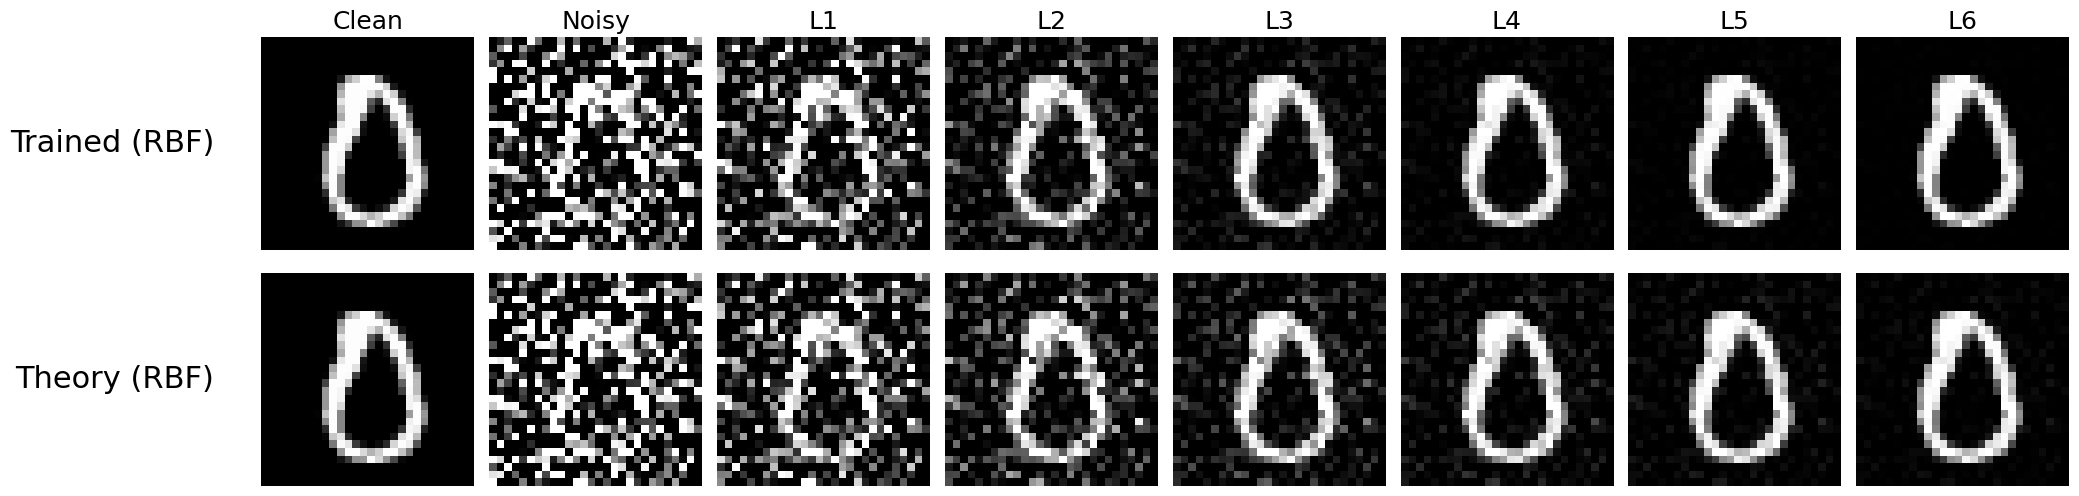

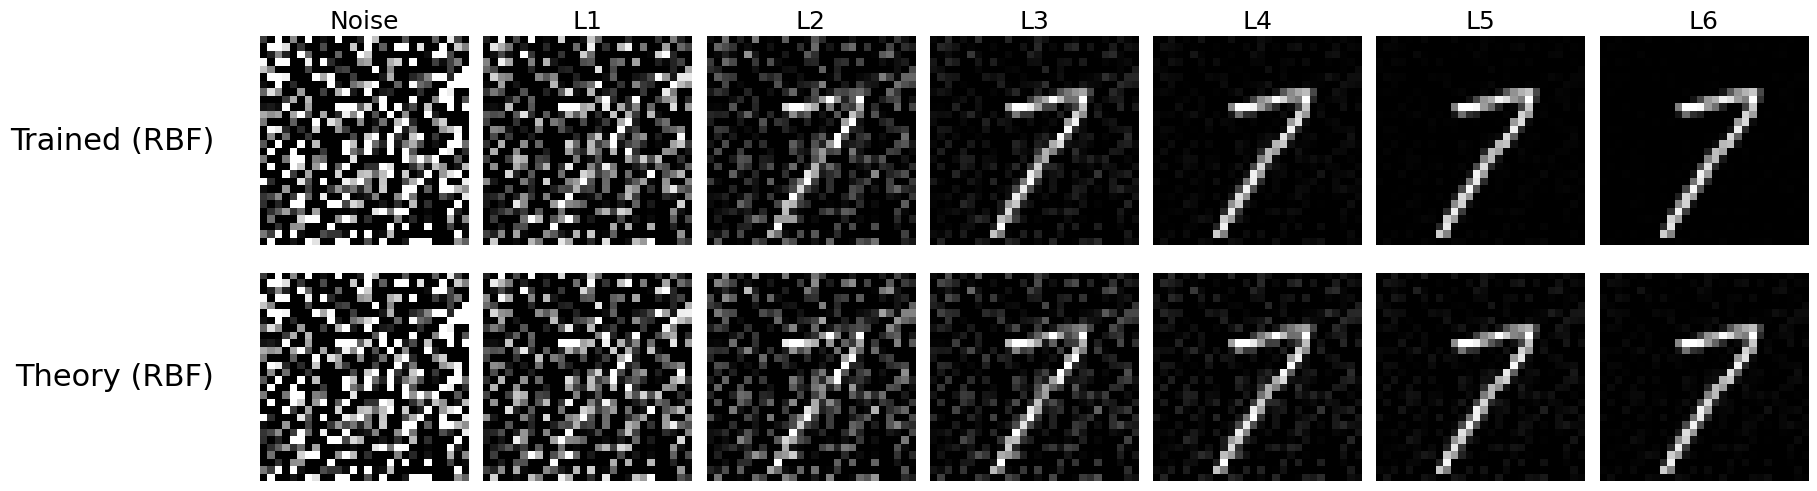

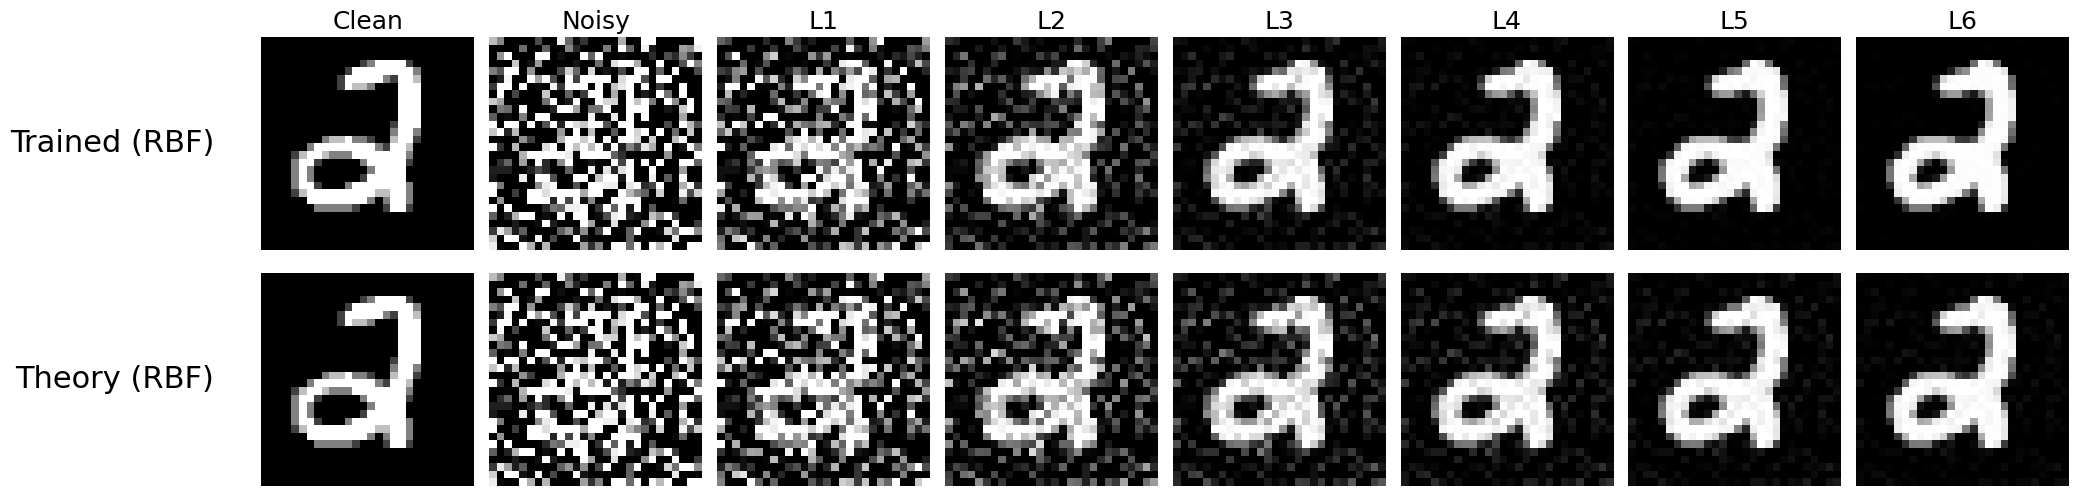


[visual] Processing cifar10...
Loading cifar10 (split seed 0)...
Files already downloaded and verified


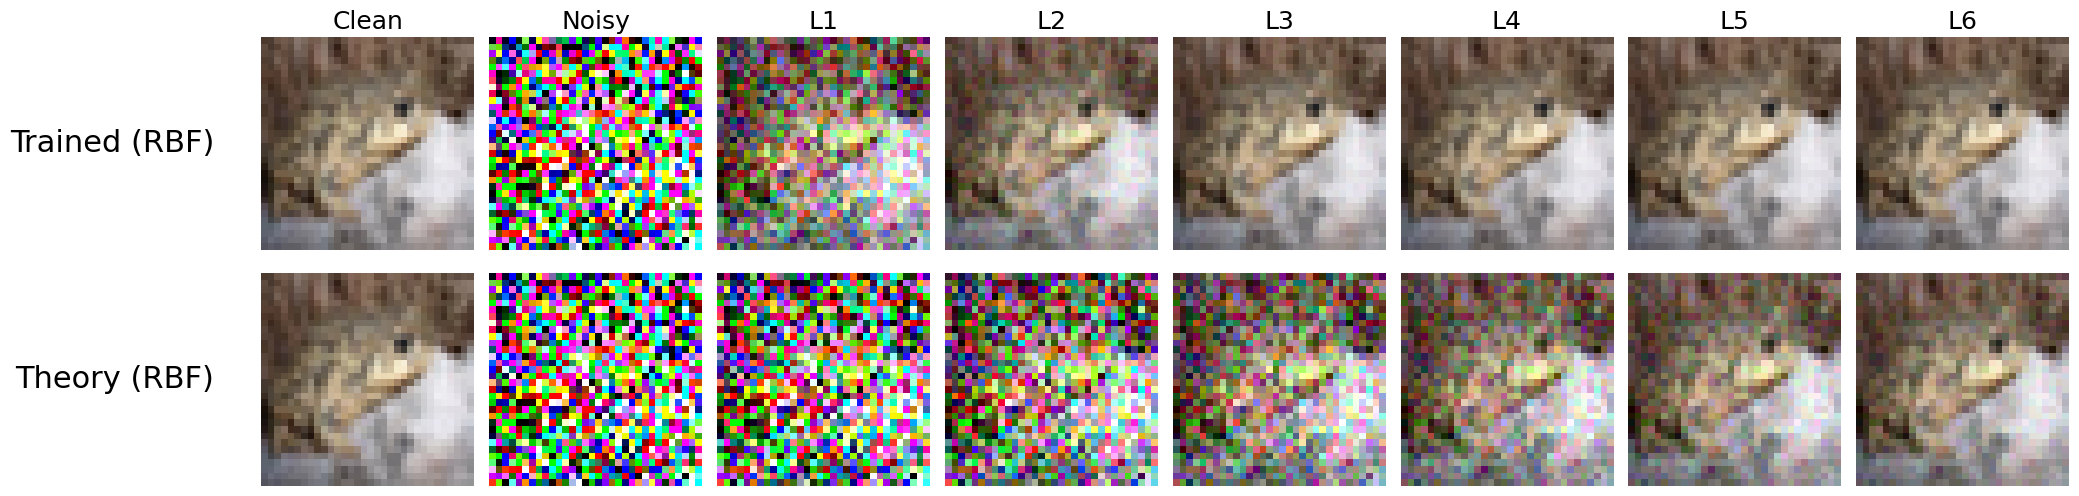

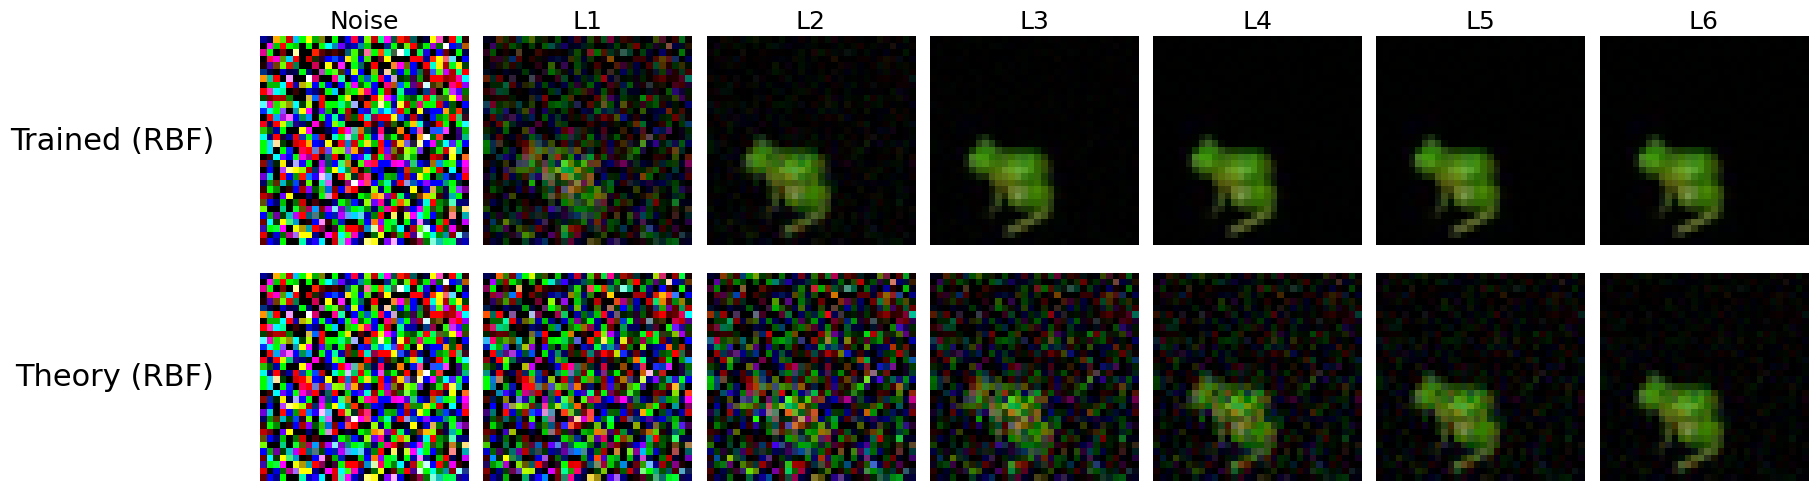

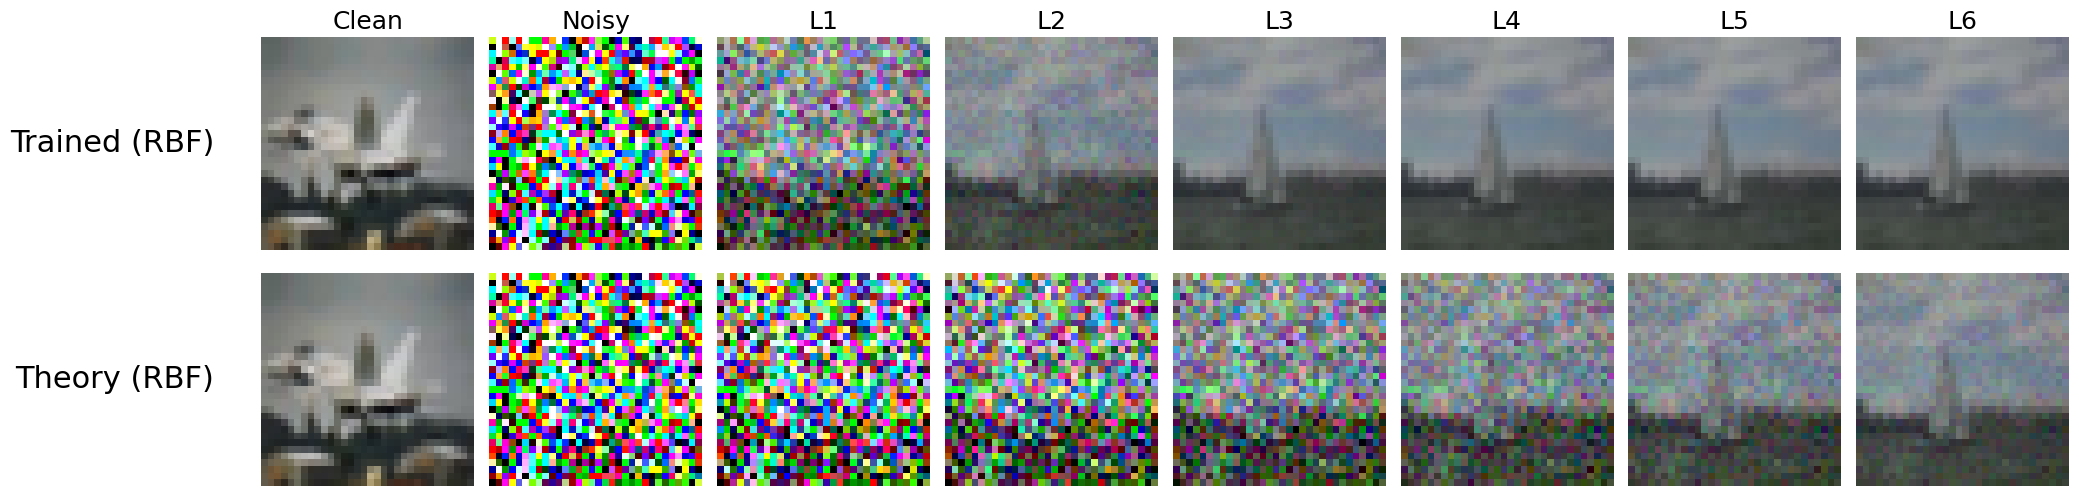


[visual] Processing cifar100...
Loading cifar100 (split seed 0)...
Files already downloaded and verified


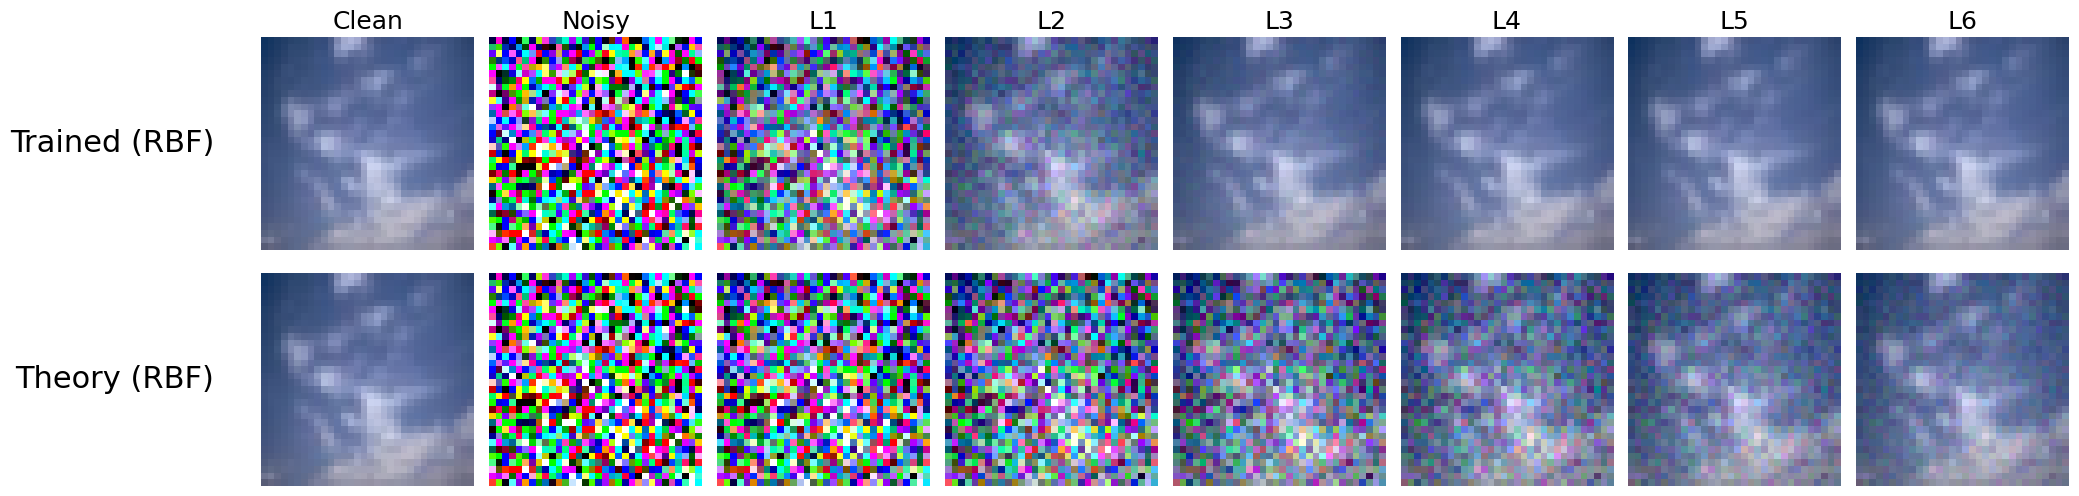

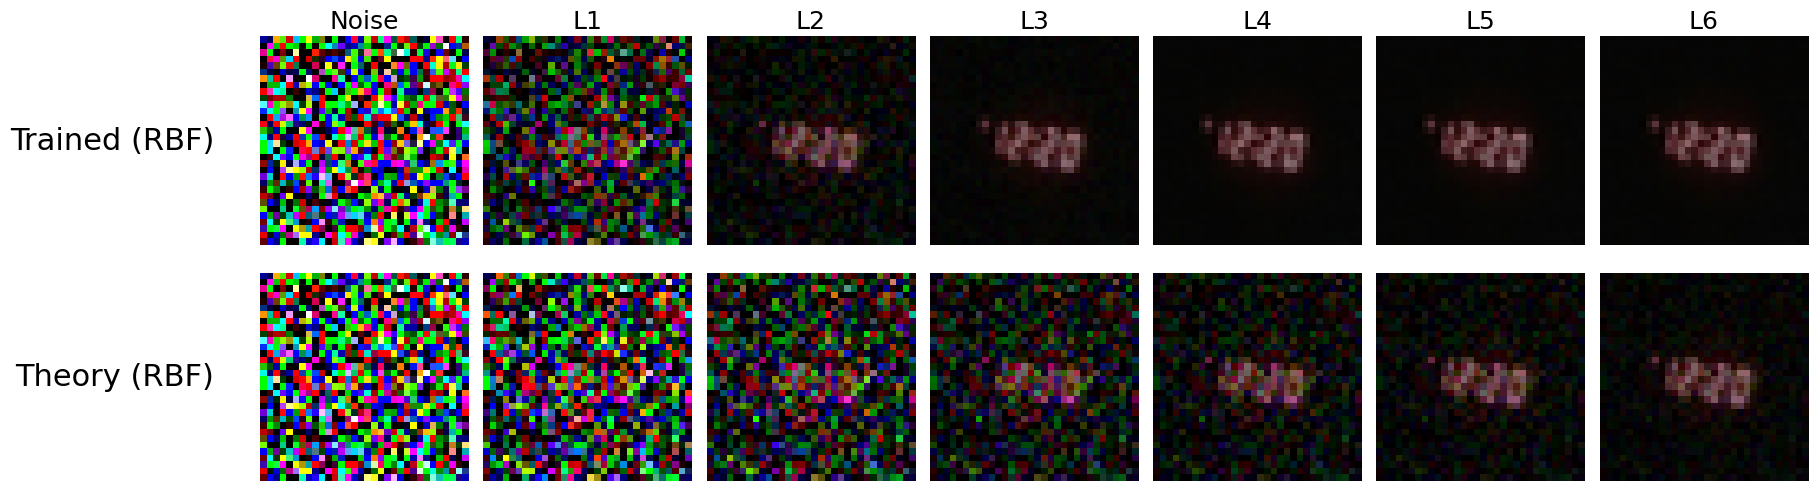

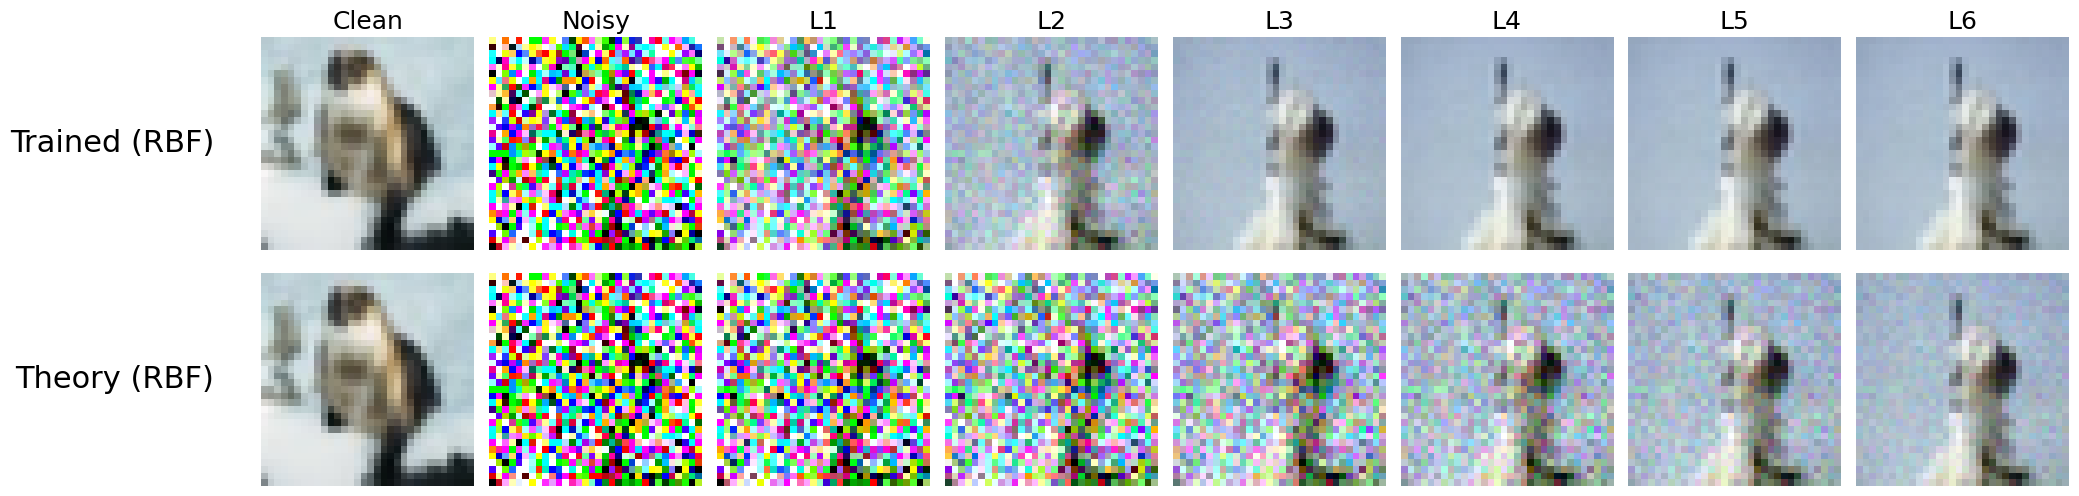

In [ ]:
#  Visualisation of denoising trajectories for individual queries (Figure 4)
#
# This cell is designed to run after the Figure 3 experiment loop above.
# It reuses:
#   • CONFIGS, NOISE_STD, DEVICE
#   • DenoiseTransformer, theory_initialise
#   • get_checkpoint_path, get_data_tensors
#
# For each dataset, we visualise RBF denoising trajectories for:
#   • a train image (in-dictionary query),
#   • a test image (out-of-dictionary query),
#   • pure Gaussian noise.
#
# Rows = different models (trained vs theory).
# Columns = clean / noisy / L1 ... L6 (or noise / L1 ... L6).

# Models to visualise for each dataset.
# "free_theory" = trained RBF model loaded from the Figure 3 checkpoints.
# "pure_theory" = RBF model with theoretical initialisation and no training.
VIS_MODELS = ["free_theory", "pure_theory"]

# Visualisation font and title options
SHOW_VIS_TITLE = False
VIS_TITLE_TEXT = "Denoising trajectories"
VIS_TITLE_FONTSIZE = 32
VIS_ROW_LABEL_FONTSIZE = 22
VIS_COL_LABEL_FONTSIZE = 18

# Datasets used in Figure 3 (mirrors the main experiment loop)
VIS_DATASETS = ["mnist", "cifar10", "cifar100"]


def build_visual_model(dataset_name: str, tag: str):
    """
    Build a single RBF denoising model for visualisation.

    For "free_theory", we load the trained RBF model from the Figure 3
    checkpoint directory for the first seed in CONFIGS[dataset]["seeds"].
    This matches the way Figure 3 reuses those checkpoints.

    For "pure_theory", we create an RBF model and initialise it using the
    same theoretical schedule used for the Figure 3 theory curves:
        σ_0 = NOISE_STD,  σ_min = 10^{-3} σ_0,  γ_* = (1 - ρ²)/2.
    """
    cfg = CONFIGS[dataset_name]
    seed = cfg["seeds"][0]

    if tag == "free_theory":
        ckpt_path = get_checkpoint_path(dataset_name, "rbf", "free", seed)
        if not ckpt_path.exists():
            print(
                f"[visual] Skipping free_theory on {dataset_name} "
                f"(checkpoint {ckpt_path.name} not found)."
            )
            return None

        model = DenoiseTransformer(TARGET_LAYER, kernel="rbf").to(DEVICE)
        state = torch.load(ckpt_path, map_location=DEVICE)
        if isinstance(state, dict) and "state_dict" in state:
            model.load_state_dict(state["state_dict"])
        else:
            model.load_state_dict(state)
        label = "Trained (RBF)"

    elif tag == "pure_theory":
        model = DenoiseTransformer(TARGET_LAYER, kernel="rbf").to(DEVICE)
        theory_initialise(model, sigma0=NOISE_STD)
        label = "Theory (RBF)"

    else:
        return None

    model.eval()
    return label, model


def build_visual_models_for_dataset(dataset_name: str):
    """
    Build all requested visualisation models for a given dataset.
    Any model whose checkpoint is missing is skipped.
    """
    models = []
    for tag in VIS_MODELS:
        built = build_visual_model(dataset_name, tag)
        if built is not None:
            models.append(built)
    if not models:
        print(f"[visual] No models available for {dataset_name}; skipping visualisation.")
    return models


def vec_to_image(dataset_name: str, vec: torch.Tensor):
    """
    Convert a flattened image vector back into an image array suitable for imshow.

    For MNIST (784 dimensions): returns a 28x28 grayscale image.
    For CIFAR-style datasets (3072 dimensions): returns a 32x32x3 RGB image.
    """
    d = CONFIGS[dataset_name]["dims"]
    v = vec.detach().view(-1).cpu().clamp(0, 1)

    if d == 784:
        img = v.view(28, 28).numpy()
        return img, "gray"
    else:
        img = v.view(3, 32, 32).permute(1, 2, 0).numpy()
        return img, None


def column_caption(kind: str, col_idx: int) -> str:
    """
    Column labels used in the visualisations.

    For "train_clean_noisy" and "test_clean_noisy":
        col 0: Clean
        col 1: Noisy
        col > 1: L_{col-1} (layer index)

    For "pure_noise":
        col 0: Noise
        col > 0: L_{col} (layer index)
    """
    if kind in ("train_clean_noisy", "test_clean_noisy"):
        if col_idx == 0:
            return "Clean"
        elif col_idx == 1:
            return "Noisy"
        else:
            return f"L{col_idx - 1}"
    elif kind == "pure_noise":
        if col_idx == 0:
            return "Noise"
        else:
            return f"L{col_idx}"
    else:
        return ""


@torch.no_grad()
def compute_layer_outputs(model: DenoiseTransformer,
                          keys: torch.Tensor,
                          start_vec: torch.Tensor):
    """
    Given a model, a dictionary of keys, and a starting query vector,
    return a list of activations along the denoising trajectory:

        [x_0, x_1, ..., x_L]

    where x_0 is the starting query and x_l is the output after l layers.
    """
    xs = [start_vec]
    x = start_vec
    for layer in model.layers:
        x = layer(keys, x)
        xs.append(x)
    return xs


def plot_grid_for_scenario(dataset_name: str,
                           models,
                           keys: torch.Tensor,
                           kind: str,
                           clean_vec: torch.Tensor | None = None,
                           noisy_vec: torch.Tensor | None = None,
                           noise_vec: torch.Tensor | None = None):
    """
    Plot a grid for a single scenario:

        kind = "train_clean_noisy" or "test_clean_noisy":
            columns: Clean, Noisy, outputs after each layer.

        kind = "pure_noise":
            columns: Noise, outputs after each layer.

    Rows correspond to different models in `models`.
    """
    if not models:
        return

    n_layers = len(models[0][1].layers)
    if kind in ("train_clean_noisy", "test_clean_noisy"):
        n_cols = 2 + n_layers
    else:
        n_cols = 1 + n_layers

    n_rows = len(models)

    fig, ax = plt.subplots(
        n_rows, n_cols,
        figsize=(2.6 * n_cols, 2.6 * n_rows)
    )
    ax = np.atleast_2d(ax)

    if SHOW_VIS_TITLE:
        fig.suptitle(VIS_TITLE_TEXT, fontsize=VIS_TITLE_FONTSIZE)

    if kind in ("train_clean_noisy", "test_clean_noisy"):
        assert clean_vec is not None and noisy_vec is not None
        base_start = noisy_vec
    else:
        assert noise_vec is not None
        base_start = noise_vec

    for r, (row_label, model) in enumerate(models):
        outs = compute_layer_outputs(model, keys, base_start)

        if kind in ("train_clean_noisy", "test_clean_noisy"):
            vectors = [clean_vec] + outs
        else:
            vectors = outs

        for c, vec in enumerate(vectors):
            img, cmap = vec_to_image(dataset_name, vec.squeeze(0))
            ax[r, c].imshow(img, cmap=cmap)
            ax[r, c].axis("off")

            if r == 0:
                col_title = column_caption(kind, c)
                if col_title:
                    ax[r, c].set_title(col_title, fontsize=VIS_COL_LABEL_FONTSIZE)

        # Row label (model name) on the left
        ax[r, 0].text(
            -0.22, 0.5, row_label,
            ha="right", va="center",
            transform=ax[r, 0].transAxes,
            fontsize=VIS_ROW_LABEL_FONTSIZE,
        )

    rect = [0, 0, 1, 0.95] if SHOW_VIS_TITLE else [0, 0, 1, 1]
    plt.tight_layout(rect=rect)
    plt.show()
    plt.close(fig)


def visualise_datasets():
    """
    For each dataset used in Figure 3, produce three visualisations:

      1. A train query whose clean image is in the dictionary.
      2. A pure-noise query.
      3. A test query whose clean image is not in the dictionary.

    Each visualisation shows the denoising trajectory across layers for
    the selected models (RBF trained vs RBF theory by default).

    To keep the dictionary consistent with the checkpoints, we use the
    same split seed as the one used to train the loaded checkpoint:
        split_seed = CONFIGS[dataset]["seeds"][0].
    """
    for dataset_name in VIS_DATASETS:
        print(f"\n[visual] Processing {dataset_name}...")
        models = build_visual_models_for_dataset(dataset_name)
        if not models:
            continue

        cfg = CONFIGS[dataset_name]
        split_seed = cfg["seeds"][0]

        # Rebuild the train/test split with the same split seed used for
        # the checkpoint corresponding to this visualisation.
        data = get_data_tensors(dataset_name, split_seed=split_seed)
        train_raw = data["train_raw"]
        test_raw = data["test_raw"]
        keys = train_raw  # RBF uses raw keys; matches Figure 3 setup.

        # 1) Train image (in-dictionary query)
        idx_train = torch.randint(
            0, train_raw.size(0), (1,), device=DEVICE
        ).item()
        clean_train = train_raw[idx_train: idx_train + 1]
        noisy_train = clean_train + NOISE_STD * torch.randn_like(clean_train)

        # 2) Test image (out-of-dictionary query)
        idx_test = torch.randint(
            0, test_raw.size(0), (1,), device=DEVICE
        ).item()
        clean_test = test_raw[idx_test: idx_test + 1]
        noisy_test = clean_test + NOISE_STD * torch.randn_like(clean_test)

        # 3) Pure noise query (same dimension as train image)
        noise_vec = NOISE_STD * torch.randn_like(clean_train)

        # Train clean/noisy scenario
        plot_grid_for_scenario(
            dataset_name,
            models,
            keys,
            kind="train_clean_noisy",
            clean_vec=clean_train,
            noisy_vec=noisy_train,
        )
        # Pure-noise scenario
        plot_grid_for_scenario(
            dataset_name,
            models,
            keys,
            kind="pure_noise",
            noise_vec=noise_vec,
        )
        # Test clean/noisy scenario
        plot_grid_for_scenario(
            dataset_name,
            models,
            keys,
            kind="test_clean_noisy",
            clean_vec=clean_test,
            noisy_vec=noisy_test,
        )


# Run the visualisation after the main Figure 3 experiment has finished.
visualise_datasets()
